In [1]:
import sys
sys.path.append('../')

import torch
import pandas as pd
import optuna
import warnings
from copy import deepcopy
from torch.utils.data import DataLoader
from src.mypackage.data_preparation import prepare_statistical_data
from src.mypackage.torch_dataset import EnergyDataset
from src.mypackage.trainer import Trainer
from src.mypackage.transformer_models import TimeSeriesTransformerModel
from src.mypackage.forecasting import dnn_forecast
from src.mypackage.evaluation import print_metrics, get_true_values
from src.mypackage.visualization import plot_forecast
from src.mypackage.utils import set_seed, SEED

warnings.filterwarnings("ignore")
set_seed(SEED)

In [2]:
# ========== データ読み込みとデータセット準備 ==========
df = pd.read_csv("../data/raw/PJME_hourly.csv")
_, tmp = prepare_statistical_data(df)
timesteps = tmp["Datetime"].copy()
del tmp
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

SEQ_LEN = 168
PRED_LEN = 24
SHIFT = 24
BATCH_SIZE = 128

# ========== データセット作成 ==========
dataset = EnergyDataset(df, seq_len=SEQ_LEN, shift=SHIFT, pred_len=PRED_LEN, mode="re-train")
retrain_dataset = deepcopy(dataset)
train_dataset = deepcopy(dataset)
train_dataset.mode_switch("train")
valid_dataset = deepcopy(dataset)
valid_dataset.mode_switch("val")
test_dataset = deepcopy(dataset)
test_dataset.mode_switch("test")

# DataLoader作成
retrain_loader = DataLoader(retrain_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Whole dataset size: {len(retrain_dataset)}")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(valid_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Input features: {train_dataset[0][0].shape[1]}")

Dataset shape: (145366, 2)
Columns: ['Datetime', 'PJME_MW']
Whole dataset size: 5654
Train dataset size: 5289
Val dataset size: 365
Test dataset size: 365
Input features: 19


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ========== ハイパーパラメータ設定 ==========
# 固定
NUM_EPOCHS = 100
INPUT_SIZE = train_dataset[0][0].shape[1]
EARLY_STOPPING_PATIENCE = 10
OUTPUT_SIZE = PRED_LEN

def objective(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    hidden_size = 2 ** trial.suggest_int("hidden_size", 4, 9)
    num_conv_layers = trial.suggest_int("num_conv_layers", 0, 3)
    if num_conv_layers > 0:
        kernel_size = trial.suggest_int("kernel_size", 3, 7)
    else:
        kernel_size = None
    num_heads = 2 ** trial.suggest_int("num_heads", 0, 4)
    dim_feedforward = 2 ** trial.suggest_int("dim_feedforward", 5, 8)
    num_layers = trial.suggest_int("num_layers", 1, 4)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)

    model = TimeSeriesTransformerModel(input_size=INPUT_SIZE, 
                                       output_channels=hidden_size, 
                                       num_conv_layers=num_conv_layers,
                                       kernel_size=kernel_size,
                                       num_layers=num_layers, 
                                       output_size=OUTPUT_SIZE, 
                                       dropout=dropout,
                                       num_heads=num_heads,
                                       dim_feedforward=dim_feedforward).to(device)

    trainer = Trainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        device=device,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        checkpoint_dir="../models/transformer_checkpoints"
    )
    history = trainer.train(num_epochs=NUM_EPOCHS, verbose=0)
    best_iteration = trainer.early_stopping.best_iteration
    trial.set_user_attr("best_iteration", best_iteration)
    return min(history['val_loss'])

Using device: cuda


In [13]:
# パラメータ探索の実行
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=50)
print(study.best_params)

[I 2026-07-22 06:53:36,940] A new study created in memory with name: no-name-2851be5f-897b-4041-999d-2b07e47e8e0b
[I 2026-07-22 06:54:33,613] Trial 0 finished with value: 0.11766684552033742 and parameters: {'learning_rate': 0.0001329291894316216, 'weight_decay': 0.0007114476009343421, 'hidden_size': 8, 'num_conv_layers': 2, 'kernel_size': 3, 'num_heads': 0, 'dim_feedforward': 5, 'num_layers': 4, 'dropout': 0.34044600469728353}. Best is trial 0 with value: 0.11766684552033742.


Checkpoint loaded from ../models/transformer_checkpoints/best_model.pt


[I 2026-07-22 06:55:13,757] Trial 1 finished with value: 0.13766653090715408 and parameters: {'learning_rate': 0.001331121608073689, 'weight_decay': 1.1527987128232402e-06, 'hidden_size': 9, 'num_conv_layers': 3, 'kernel_size': 4, 'num_heads': 0, 'dim_feedforward': 5, 'num_layers': 2, 'dropout': 0.3099025726528951}. Best is trial 0 with value: 0.11766684552033742.


Checkpoint loaded from ../models/transformer_checkpoints/best_model.pt


[I 2026-07-22 06:55:52,506] Trial 2 finished with value: 0.11857513338327408 and parameters: {'learning_rate': 0.00019762189340280086, 'weight_decay': 7.4763120622522945e-06, 'hidden_size': 7, 'num_conv_layers': 0, 'num_heads': 1, 'dim_feedforward': 6, 'num_layers': 2, 'dropout': 0.41407038455720546}. Best is trial 0 with value: 0.11766684552033742.


...

Checkpoint loaded from ../models/transformer_checkpoints/best_model.pt


[I 2026-07-22 07:46:37,073] Trial 48 finished with value: 0.922192762295405 and parameters: {'learning_rate': 0.005008597603491364, 'weight_decay': 0.0006476594839092053, 'hidden_size': 9, 'num_conv_layers': 3, 'kernel_size': 7, 'num_heads': 3, 'dim_feedforward': 6, 'num_layers': 3, 'dropout': 0.11887643764365947}. Best is trial 16 with value: 0.08228285610675812.


Checkpoint loaded from ../models/transformer_checkpoints/best_model.pt


[I 2026-07-22 07:47:04,924] Trial 49 finished with value: 0.09975729137659073 and parameters: {'learning_rate': 0.0029282990264694075, 'weight_decay': 0.0001481442654659701, 'hidden_size': 7, 'num_conv_layers': 2, 'kernel_size': 6, 'num_heads': 4, 'dim_feedforward': 8, 'num_layers': 3, 'dropout': 0.2522362410026878}. Best is trial 16 with value: 0.08228285610675812.


Checkpoint loaded from ../models/transformer_checkpoints/best_model.pt
{'learning_rate': 0.0013116452991056213, 'weight_decay': 1.7825601965382193e-05, 'hidden_size': 6, 'num_conv_layers': 2, 'kernel_size': 6, 'num_heads': 3, 'dim_feedforward': 8, 'num_layers': 3, 'dropout': 0.10527168575236939}


In [14]:
def has_kernel_size(study):
    return "kernel_size" in study.best_params

kernel_size = study.best_params["kernel_size"] if has_kernel_size(study) else None

In [15]:
# モデルの再学習（1日予測）
model = TimeSeriesTransformerModel(input_size=INPUT_SIZE,
                                   output_channels=2**study.best_params["hidden_size"],
                                   num_conv_layers=study.best_params["num_conv_layers"],
                                   kernel_size=kernel_size,
                                   output_size=OUTPUT_SIZE,
                                   num_heads=2**study.best_params["num_heads"],
                                   dim_feedforward=2**study.best_params["dim_feedforward"],
                                   num_layers=study.best_params["num_layers"],
                                   dropout=study.best_params["dropout"]).to(device)

trainer = Trainer(model=model,
                  train_loader=retrain_loader,
                  test_loader=test_loader,
                  device=device,
                  learning_rate=study.best_params["learning_rate"],
                  weight_decay=study.best_params["weight_decay"],
                  checkpoint_dir="../models/transformer_checkpoints")

history = trainer.train(num_epochs=study.best_trial.user_attrs["best_iteration"], verbose=True)

Epoch [4/44] - Train Loss: 0.143654, Val Loss: nan - Train MAE: 0.289155, Val MAE: nan
Epoch [8/44] - Train Loss: 0.119515, Val Loss: nan - Train MAE: 0.260562, Val MAE: nan
Epoch [12/44] - Train Loss: 0.110186, Val Loss: nan - Train MAE: 0.250171, Val MAE: nan
Epoch [16/44] - Train Loss: 0.096544, Val Loss: nan - Train MAE: 0.232784, Val MAE: nan
Epoch [20/44] - Train Loss: 0.092478, Val Loss: nan - Train MAE: 0.226784, Val MAE: nan
Epoch [24/44] - Train Loss: 0.093890, Val Loss: nan - Train MAE: 0.229663, Val MAE: nan
Epoch [28/44] - Train Loss: 0.084046, Val Loss: nan - Train MAE: 0.215407, Val MAE: nan
Epoch [32/44] - Train Loss: 0.082990, Val Loss: nan - Train MAE: 0.214007, Val MAE: nan
Epoch [36/44] - Train Loss: 0.081045, Val Loss: nan - Train MAE: 0.211439, Val MAE: nan
Epoch [40/44] - Train Loss: 0.077549, Val Loss: nan - Train MAE: 0.206464, Val MAE: nan
Epoch [44/44] - Train Loss: 0.076043, Val Loss: nan - Train MAE: 0.204094, Val MAE: nan
No best model checkpoint found; sa

In [16]:
# ========== テストデータで評価 ==========
test_loss, test_mae, test_rmse = trainer.test()
print("\nTest Metrics:")
print(f"  Test Loss (MSE): {test_loss:.6f}")
print(f"  Test MAE: {test_mae:.6f}")
print(f"  Test RMSE: {test_rmse:.6f}")

# チェックポイントとコンフィグの保存
trainer.save_checkpoint("../models/transformer_checkpoints/day_best_model.pth")
trainer.save_config("../models/transformer_checkpoints/day_best_model_config.json")


Test Metrics:
  Test Loss (MSE): 0.114140
  Test MAE: 0.231845
  Test RMSE: 0.334168
Checkpoint saved to ../models/transformer_checkpoints/day_best_model.pth
Configuration saved to ../models/transformer_checkpoints/day_best_model_config.json


In [17]:
# 1週間予測用のデータセット
dataset_week = EnergyDataset(df, seq_len=SEQ_LEN, shift=SHIFT, pred_len=7*PRED_LEN, mode="re-train")
test_dataset_week = deepcopy(dataset_week)
test_dataset_week.mode_switch("test")

train_loader_week = DataLoader(dataset_week, batch_size=BATCH_SIZE, shuffle=True)
test_loader_week = DataLoader(test_dataset_week, batch_size=BATCH_SIZE, shuffle=False)

In [18]:
# モデルの再学習（1週間予測）
model = TimeSeriesTransformerModel(input_size=INPUT_SIZE,
                                   output_channels=2**study.best_params["hidden_size"],
                                   num_conv_layers=study.best_params["num_conv_layers"],
                                   kernel_size=kernel_size,
                                   output_size=7*PRED_LEN,
                                   num_heads=2**study.best_params["num_heads"],
                                   dim_feedforward=2**study.best_params["dim_feedforward"],
                                   num_layers=study.best_params["num_layers"],
                                   dropout=study.best_params["dropout"]).to(device)

trainer = Trainer(model=model,
                  train_loader=train_loader_week,
                  test_loader=test_loader_week,
                  device=device,
                  learning_rate=study.best_params["learning_rate"],
                  weight_decay=study.best_params["weight_decay"],
                  checkpoint_dir="../models/transformer_checkpoints")

history = trainer.train(num_epochs=study.best_trial.user_attrs["best_iteration"], verbose=True)

Epoch [4/44] - Train Loss: 0.298989, Val Loss: nan - Train MAE: 0.417524, Val MAE: nan
Epoch [8/44] - Train Loss: 0.257028, Val Loss: nan - Train MAE: 0.383570, Val MAE: nan
Epoch [12/44] - Train Loss: 0.232110, Val Loss: nan - Train MAE: 0.364133, Val MAE: nan
Epoch [16/44] - Train Loss: 0.215230, Val Loss: nan - Train MAE: 0.348361, Val MAE: nan
Epoch [20/44] - Train Loss: 0.206203, Val Loss: nan - Train MAE: 0.341386, Val MAE: nan
Epoch [24/44] - Train Loss: 0.195760, Val Loss: nan - Train MAE: 0.331673, Val MAE: nan
Epoch [28/44] - Train Loss: 0.186050, Val Loss: nan - Train MAE: 0.324983, Val MAE: nan
Epoch [32/44] - Train Loss: 0.177275, Val Loss: nan - Train MAE: 0.317351, Val MAE: nan
Epoch [36/44] - Train Loss: 0.175339, Val Loss: nan - Train MAE: 0.316343, Val MAE: nan
Epoch [40/44] - Train Loss: 0.166727, Val Loss: nan - Train MAE: 0.308729, Val MAE: nan
Epoch [44/44] - Train Loss: 0.158248, Val Loss: nan - Train MAE: 0.300691, Val MAE: nan
No best model checkpoint found; sa

In [19]:
# ========== テストデータで評価 ==========
test_loss, test_mae, test_rmse = trainer.test()
print("\nTest Metrics:")
print(f"  Test Loss (MSE): {test_loss:.6f}")
print(f"  Test MAE: {test_mae:.6f}")
print(f"  Test RMSE: {test_rmse:.6f}")

# チェックポイントとコンフィグの保存
trainer.save_checkpoint("../models/transformer_checkpoints/week_best_model.pth")
trainer.save_config("../models/transformer_checkpoints/week_best_model_config.json")


Test Metrics:
  Test Loss (MSE): 0.322689
  Test MAE: 0.413642
  Test RMSE: 0.568057
Checkpoint saved to ../models/transformer_checkpoints/week_best_model.pth
Configuration saved to ../models/transformer_checkpoints/week_best_model_config.json


In [20]:
# 1か月予測用のデータセット
dataset_month = EnergyDataset(df, seq_len=SEQ_LEN, shift=SHIFT, pred_len=30*PRED_LEN, mode="re-train")
test_dataset_month = deepcopy(dataset_month)
test_dataset_month.mode_switch("test")

train_loader_month = DataLoader(dataset_month, batch_size=BATCH_SIZE, shuffle=True)
test_loader_month = DataLoader(test_dataset_month, batch_size=BATCH_SIZE, shuffle=False)

In [21]:
# モデルの再学習（1か月予測）
model = TimeSeriesTransformerModel(input_size=INPUT_SIZE,
                                   output_channels=2**study.best_params["hidden_size"],
                                   num_conv_layers=study.best_params["num_conv_layers"],
                                   kernel_size=kernel_size,
                                   output_size=30*PRED_LEN,
                                   num_heads=2**study.best_params["num_heads"],
                                   dim_feedforward=2**study.best_params["dim_feedforward"],
                                   num_layers=study.best_params["num_layers"],
                                   dropout=study.best_params["dropout"]).to(device)

trainer = Trainer(model=model,
                  train_loader=train_loader_month,
                  test_loader=test_loader_month,
                  device=device,
                  learning_rate=study.best_params["learning_rate"],
                  weight_decay=study.best_params["weight_decay"],
                  checkpoint_dir="../models/transformer_checkpoints")

history = trainer.train(num_epochs=study.best_trial.user_attrs["best_iteration"], verbose=True)

Epoch [4/44] - Train Loss: 0.340581, Val Loss: nan - Train MAE: 0.447114, Val MAE: nan
Epoch [8/44] - Train Loss: 0.274336, Val Loss: nan - Train MAE: 0.398161, Val MAE: nan
Epoch [12/44] - Train Loss: 0.257851, Val Loss: nan - Train MAE: 0.384616, Val MAE: nan
Epoch [16/44] - Train Loss: 0.246587, Val Loss: nan - Train MAE: 0.375470, Val MAE: nan
Epoch [20/44] - Train Loss: 0.229280, Val Loss: nan - Train MAE: 0.360581, Val MAE: nan
Epoch [24/44] - Train Loss: 0.222540, Val Loss: nan - Train MAE: 0.354243, Val MAE: nan
Epoch [28/44] - Train Loss: 0.214735, Val Loss: nan - Train MAE: 0.347850, Val MAE: nan
Epoch [32/44] - Train Loss: 0.210857, Val Loss: nan - Train MAE: 0.344391, Val MAE: nan
Epoch [36/44] - Train Loss: 0.205686, Val Loss: nan - Train MAE: 0.339646, Val MAE: nan
Epoch [40/44] - Train Loss: 0.199159, Val Loss: nan - Train MAE: 0.333640, Val MAE: nan
Epoch [44/44] - Train Loss: 0.195449, Val Loss: nan - Train MAE: 0.330917, Val MAE: nan
No best model checkpoint found; sa

In [22]:
# ========== テストデータで評価 ==========
test_loss, test_mae, test_rmse = trainer.test()
print("\nTest Metrics:")
print(f"  Test Loss (MSE): {test_loss:.6f}")
print(f"  Test MAE: {test_mae:.6f}")
print(f"  Test RMSE: {test_rmse:.6f}")

# チェックポイントとコンフィグの保存
trainer.save_checkpoint("../models/transformer_checkpoints/month_best_model.pth")
trainer.save_config("../models/transformer_checkpoints/month_best_model_config.json")


Test Metrics:
  Test Loss (MSE): 0.338293
  Test MAE: 0.418750
  Test RMSE: 0.581630
Checkpoint saved to ../models/transformer_checkpoints/month_best_model.pth
Configuration saved to ../models/transformer_checkpoints/month_best_model_config.json


In [23]:
# 1年予測用のデータセット
dataset_year = EnergyDataset(df, seq_len=SEQ_LEN, shift=SHIFT, pred_len=365*PRED_LEN, mode="re-train")
test_dataset_year = deepcopy(dataset_year)
test_dataset_year.mode_switch("test")

train_loader_year = DataLoader(dataset_year, batch_size=BATCH_SIZE, shuffle=True)
test_loader_year = DataLoader(test_dataset_year, batch_size=BATCH_SIZE, shuffle=False)

In [24]:
# モデルの再学習（1年予測）
model = TimeSeriesTransformerModel(input_size=INPUT_SIZE,
                                   output_channels=2**study.best_params["hidden_size"],
                                   num_conv_layers=study.best_params["num_conv_layers"],
                                   kernel_size=kernel_size,
                                   output_size=365*PRED_LEN,
                                   num_heads=2**study.best_params["num_heads"],
                                   dim_feedforward=2**study.best_params["dim_feedforward"],
                                   num_layers=study.best_params["num_layers"],
                                   dropout=study.best_params["dropout"]).to(device)

trainer = Trainer(model=model,
                  train_loader=train_loader_year,
                  test_loader=test_loader_year,
                  device=device,
                  learning_rate=study.best_params["learning_rate"],
                  weight_decay=study.best_params["weight_decay"],
                  checkpoint_dir="../models/transformer_checkpoints")

history = trainer.train(num_epochs=study.best_trial.user_attrs["best_iteration"], verbose=True)

Epoch [4/44] - Train Loss: 0.436406, Val Loss: nan - Train MAE: 0.501271, Val MAE: nan
Epoch [8/44] - Train Loss: 0.348400, Val Loss: nan - Train MAE: 0.450874, Val MAE: nan
Epoch [12/44] - Train Loss: 0.296469, Val Loss: nan - Train MAE: 0.415641, Val MAE: nan
Epoch [16/44] - Train Loss: 0.274674, Val Loss: nan - Train MAE: 0.397620, Val MAE: nan
Epoch [20/44] - Train Loss: 0.265448, Val Loss: nan - Train MAE: 0.390227, Val MAE: nan
Epoch [24/44] - Train Loss: 0.256153, Val Loss: nan - Train MAE: 0.382247, Val MAE: nan
Epoch [28/44] - Train Loss: 0.245040, Val Loss: nan - Train MAE: 0.372341, Val MAE: nan
Epoch [32/44] - Train Loss: 0.242010, Val Loss: nan - Train MAE: 0.369654, Val MAE: nan
Epoch [36/44] - Train Loss: 0.237900, Val Loss: nan - Train MAE: 0.366140, Val MAE: nan
Epoch [40/44] - Train Loss: 0.236176, Val Loss: nan - Train MAE: 0.364492, Val MAE: nan
Epoch [44/44] - Train Loss: 0.234109, Val Loss: nan - Train MAE: 0.362800, Val MAE: nan
No best model checkpoint found; sa

In [26]:
# ========== テストデータで評価 ==========
test_loss, test_mae, test_rmse = trainer.test()
print("\nTest Metrics:")
print(f"  Test Loss (MSE): {test_loss:.6f}")
print(f"  Test MAE: {test_mae:.6f}")
print(f"  Test RMSE: {test_rmse:.6f}")

# チェックポイントとコンフィグの保存
trainer.save_checkpoint("../models/transformer_checkpoints/year_best_model.pth")
trainer.save_config("../models/transformer_checkpoints/year_best_model_config.json")


Test Metrics:
  Test Loss (MSE): 0.323485
  Test MAE: 0.432301
  Test RMSE: 0.568758
Checkpoint saved to ../models/transformer_checkpoints/year_best_model.pth
Configuration saved to ../models/transformer_checkpoints/year_best_model_config.json


In [27]:
# チェックポイントの読み込みと再学習
checkpoint_day = torch.load("../models/transformer_checkpoints/day_best_model.pth", map_location=device)
params_day = checkpoint_day["model_config"]
model_day = TimeSeriesTransformerModel(**params_day).to(device)
model_day.load_state_dict(checkpoint_day["model_state_dict"])

checkpoint_week = torch.load("../models/transformer_checkpoints/week_best_model.pth", map_location=device)
params_week = checkpoint_week["model_config"]
model_week = TimeSeriesTransformerModel(**params_week).to(device)
model_week.load_state_dict(checkpoint_week["model_state_dict"])

checkpoint_month = torch.load("../models/transformer_checkpoints/month_best_model.pth", map_location=device)
params_month = checkpoint_month["model_config"]
model_month = TimeSeriesTransformerModel(**params_month).to(device)
model_month.load_state_dict(checkpoint_month["model_state_dict"])

checkpoint_year = torch.load("../models/transformer_checkpoints/year_best_model.pth", map_location=device)
params_year = checkpoint_year["model_config"]
model_year = TimeSeriesTransformerModel(**params_year).to(device)
model_year.load_state_dict(checkpoint_year["model_state_dict"])

<All keys matched successfully>

In [28]:
y_true = get_true_values(test_loader, dataset)

y_pred_day = dnn_forecast(model_day, test_loader, dataset, device)
y_pred_week = dnn_forecast(model_week, test_loader_week, dataset, device)[-len(y_true):]
y_pred_month = dnn_forecast(model_month, test_loader_month, dataset, device)[-len(y_true):]
y_pred_year = dnn_forecast(model_year, test_loader_year, dataset, device)

In [29]:
print_metrics(y_true, y_pred_day, "Transformer Forecast (1 Day)")
print_metrics(y_true, y_pred_week, "Transformer Forecast (1 Week)")
print_metrics(y_true, y_pred_month, "Transformer Forecast (1 Month)")
print_metrics(y_true, y_pred_year, "Transformer Forecast (1 Year)")

Transformer Forecast (1 Day):
MAE: 1502.55
RMSE: 2186.26
MAPE: 4.65%

Transformer Forecast (1 Week):
MAE: 3590.31
RMSE: 4779.82
MAPE: 11.40%

Transformer Forecast (1 Month):
MAE: 4208.81
RMSE: 5420.21
MAPE: 13.27%

Transformer Forecast (1 Year):
MAE: 3889.46
RMSE: 5060.17
MAPE: 12.46%



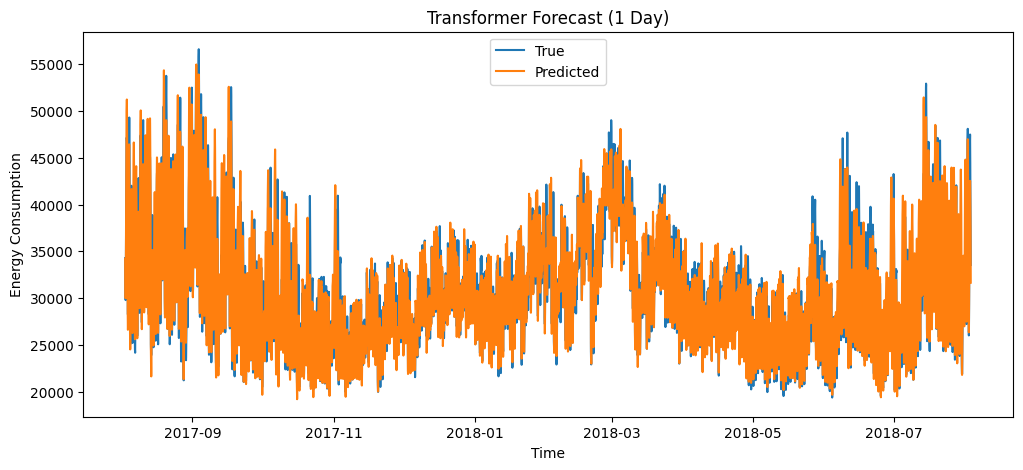

In [30]:
plot_forecast(y_true, y_pred_day, timesteps, "Transformer Forecast (1 Day)")

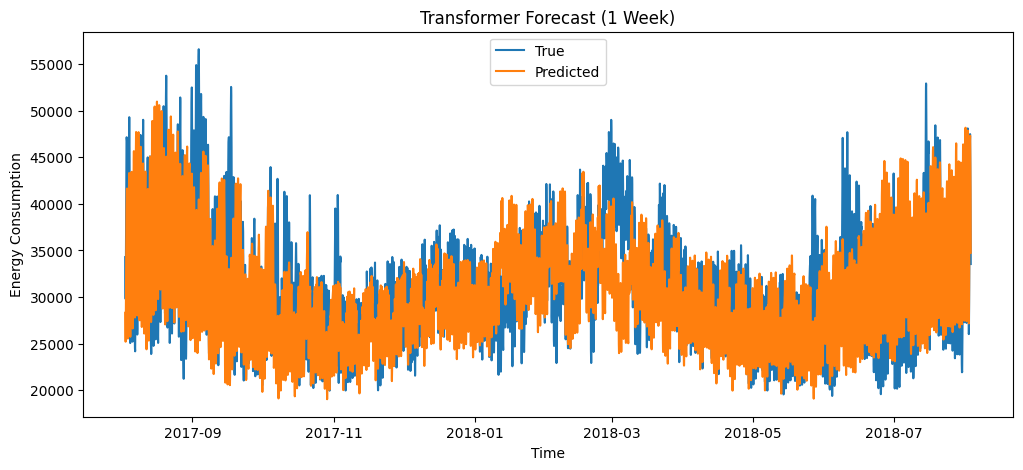

In [31]:
plot_forecast(y_true, y_pred_week, timesteps, "Transformer Forecast (1 Week)")

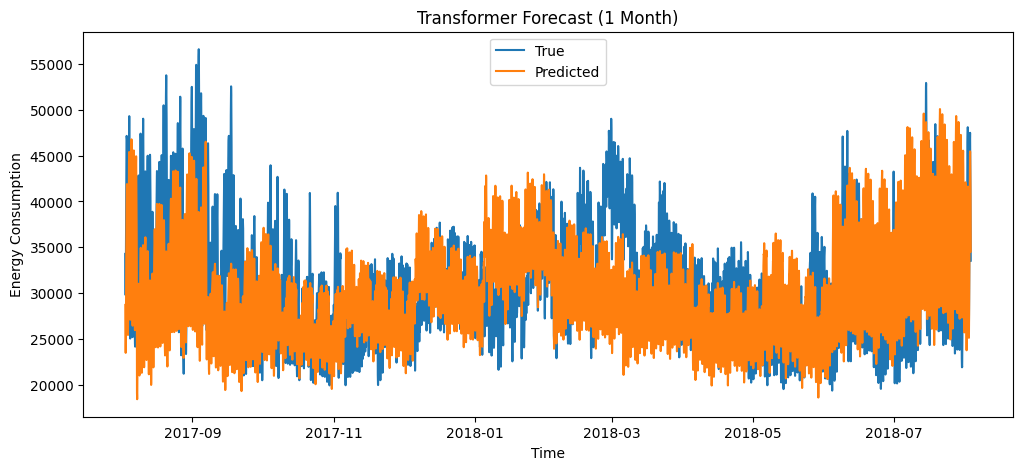

In [32]:
plot_forecast(y_true, y_pred_month, timesteps, "Transformer Forecast (1 Month)")

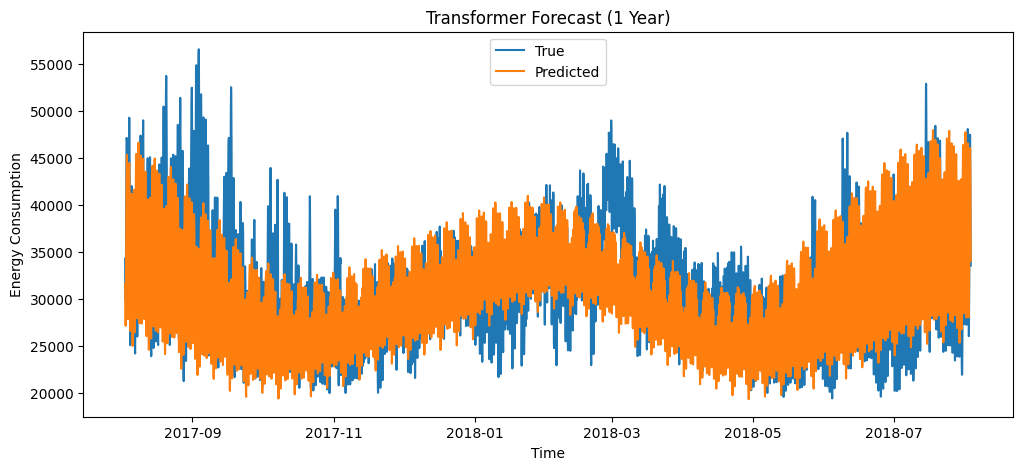

In [33]:
plot_forecast(y_true, y_pred_year, timesteps, "Transformer Forecast (1 Year)")